In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [11]:
gdf = gpd.read_file('C:\\Users\\enzo.choffat\\Downloads\\GOL_fermetures_chalut\\Bande_0-3 miles\\Pol3mn.shx')
print(gdf.head())

   id                                           geometry
0  14  MULTIPOLYGON (((5.5424 43.21011, 5.54145 43.12...


In [12]:
print(gdf.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        1 non-null      int64   
 1   geometry  1 non-null      geometry
dtypes: geometry(1), int64(1)
memory usage: 148.0 bytes
None


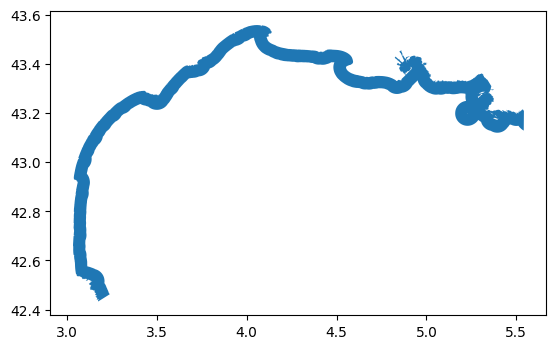

In [13]:
gdf.plot()
plt.show()

In [1]:
import re

def parse_dmm_to_decimal(coord_str):
    coord_str = coord_str.replace(',', '.').replace('°', ' ').replace('’', ' ').replace(';', ' ')
    match = re.search(r"(\d+)\s+([\d\.]+)\s*([NSEW])", coord_str, re.IGNORECASE)

    if not match:
        raise ValueError("format")

    deg = float(match.group(1))
    minutes = float(match.group(2))
    direction = match.group(3).upper()

    decimal = deg + (minutes / 60.0)

    if direction in ['S', 'W']:
        decimal = -decimal

    return decimal

In [2]:
def parse_zone_string(text):
    points_str = re.split(r'\s–\s|\s-\s', text.split(':')[1])

    coords_list = []

    for p in points_str:
        parts = p.split(';')
        if len(parts) != 2:
            continue

        lat_str = parts[0].strip()
        lon_str = parts[1].strip()

        lat = parse_dmm_to_decimal(lat_str)
        lon = parse_dmm_to_decimal(lon_str)

        coords_list.append((lon, lat))

    return coords_list

In [4]:
import geopandas as gpd
from shapely.geometry import Polygon
import re

# Données brutes fournies
raw_data = [
    "Zone 1: 42°45,300’N ; 3°37,050’E – 42°45,300’N ; 3°41,086’E – 42°41,268’N ; 3°41,086’E – 42°41,268’N ; 3°37,050’E",
    "Zone 2: 42°52,95’N ; 4°2,95’E – 42°52,95’N ; 4°7,32’E – 42°48,9’N ; 4°7,32’E  – 42°48,9’N ; 4°2,95’E",
    "Zone 3: 43° N ; 4°49,35’E – 43° N ; 4°53,7’E – 42°55,896’N ; 4°53,7’E – 42°55,896’N ; 4°49,35’E"
]

def parse_dmm_to_decimal(coord_str):
    """
    Convertit une chaîne '42°45,300’N', '43° N' ou '4°2,95’E' en degrés décimaux.
    Gère les cas sans minutes, les virgules françaises et les espaces variables.
    """
    coord_str = coord_str.strip().replace(',', '.')
    
    # Cas 1 : Degrés seulement (ex: "43° N")
    if re.match(r"^\d+\s*°\s*[NSEW]$", coord_str, re.IGNORECASE):
        match = re.search(r"(\d+)\s*°\s*([NSEW])", coord_str, re.IGNORECASE)
        deg = float(match.group(1))
        direction = match.group(2).upper()
        minutes = 0.0
    # Cas 2 : Degrés et Minutes (ex: "42°45,300’N" ou "4°2,95’E")
    else:
        # Regex flexible pour capturer degrés, minutes et direction
        match = re.search(r"(\d+)\s*°\s*([\d\.]+)\s*[’']?\s*([NSEW])", coord_str, re.IGNORECASE)
        if not match:
            raise ValueError(f"Format de coordonnée incompris : {coord_str}")
        deg = float(match.group(1))
        minutes = float(match.group(2))
        direction = match.group(3).upper()
    
    decimal = deg + (minutes / 60.0)
    
    if direction in ['S', 'W']:
        decimal = -decimal
        
    return decimal

def parse_zone_string(text):
    """Extrait le nom de la zone et la liste des coordonnées (Lon, Lat)"""
    # Séparer le nom (avant :) et les coordonnées (après :)
    parts = text.split(':')
    zone_name = parts[0].strip()
    coords_part = parts[1]
    
    # Séparer les points par le tiret (gère les tirets longs et courts, avec espaces)
    points_str = re.split(r'\s–\s|\s-\s', coords_part)
    
    coords_list = []
    
    for p in points_str:
        p = p.strip()
        if not p:
            continue
        # Séparer Latitude et Longitude par le point-virgule
        lat_lon_parts = p.split(';')
        if len(lat_lon_parts) != 2:
            continue
            
        lat_str = lat_lon_parts[0].strip()
        lon_str = lat_lon_parts[1].strip()
        
        lat = parse_dmm_to_decimal(lat_str)
        lon = parse_dmm_to_decimal(lon_str)
        
        # Format pour Shapely : (Longitude, Latitude)
        coords_list.append((lon, lat))
    
    return zone_name, coords_list

# Listes pour stocker les résultats
geometries = []
attributes = {
    "nom_zone": [],
    "nb_sommets": [],
    "surface_km2": []
}

print("Traitement des zones en cours...\n")

for line in raw_data:
    try:
        name, coords = parse_zone_string(line)
        
        # Vérification fermeture du polygone
        if coords[0] != coords[-1]:
            coords.append(coords[0])
            
        polygon = Polygon(coords)
        geometries.append(polygon)
        
        # Calcul de la surface (projection temporaire en Lambert-93 pour précision)
        # On crée un GeoDataFrame temporaire juste pour le calcul de surface
        gdf_temp = gpd.GeoDataFrame(geometry=[polygon], crs="EPSG:4326")
        gdf_temp_proj = gdf_temp.to_crs(epsg=2154) # Lambert-93 (mètres)
        area_km2 = gdf_temp_proj.geometry.area.iloc[0] / 1_000_000
        
        # Stockage des données
        attributes["nom_zone"].append(name)
        attributes["nb_sommets"].append(len(coords))
        attributes["surface_km2"].append(round(area_km2, 4))
        
        print(f"✓ {name} : {len(coords)} sommets, Surface ≈ {area_km2:.4f} km²")
        
    except Exception as e:
        print(f"✗ Erreur sur {line.split(':')[0]} : {e}")

# Création du GeoDataFrame final
if geometries:
    gdf_final = gpd.GeoDataFrame(attributes, geometry=geometries)
    gdf_final.set_crs(epsg=4326, inplace=True)
    
    # Export en Shapefile
    output_file = "zones_concessions.shp"
    gdf_final.to_file(output_file, driver='ESRI Shapefile')
    
    print(f"\n✅ Succès ! Fichier '{output_file}' créé avec {len(geometries)} polygones.")
    print("Fichiers générés : .shp, .shx, .dbf, .prj")
else:
    print("\n❌ Aucun polygone n'a pu être créé.")

Traitement des zones en cours...

✓ Zone 1 : 5 sommets, Surface ≈ 41.2286 km²
✓ Zone 2 : 5 sommets, Surface ≈ 44.7364 km²
✓ Zone 3 : 5 sommets, Surface ≈ 45.0298 km²

✅ Succès ! Fichier 'zones_concessions.shp' créé avec 3 polygones.
Fichiers générés : .shp, .shx, .dbf, .prj


C:\Users\enzo.choffat\AppData\Local\Temp\ipykernel_29548\3134659892.py:118: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_final.to_file(output_file, driver='ESRI Shapefile')
c:\Users\enzo.choffat\Documents\Stage\code\diatome\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'surface_km2' to 'surface_km'
  ogr_write(
